In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
from collections import defaultdict
from matplotlib.ticker import StrMethodFormatter
import matplotlib.patches as mpatches


/tmp/ipykernel_2052456/2772034290.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
named = {
    "rtasipp": "RTAS",
    "plrtosipp": "MaxATFS",
    "hybrid": "MedATFS",
    "plrtosipphonly": "PLRTS"
}

colord = {
    "plrtosipphonly": "k",
    "rtasipp": "b",
    "hybrid": "r",
    "plrtosipp": "g"
    
    
}
plt.rcParams.update({'font.size': 16})

In [ ]:
def plot_figure(title, folder, pattern, name, upper, num, legend =False):
    dat = []
    print(len(glob(folder + pattern)))
    for file_name in glob(folder + pattern):
        fn = file_name.replace(folder,"")
        try:
            #print(fn.replace(".out", "").split("_"))
            map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
        except:
            continue
        lookahead = int(lookahead)
        cost = float("inf")
        expansions = float("inf")
        search_time = float("inf")
        learn_time = float("inf")
        with open(file_name) as f:
            for line in f.readlines():
                if "Arrival time:" in line:
                    cost = float(line.split(": ")[1])
                if "Nodes expanded:" in line:
                    expansions = int(line.split("Nodes expanded: ")[1].split()[0])
                if "Search:" in line:
                    search_time = line.split()[1]
                    learn_time = line.split()[4]
                    assert(line.split()[2] == "ms")
                    assert(line.split()[5] == "ms")
        dat.append((map, alg, lookahead, rep, expansions, cost))
    data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost"])
    plt.figure(figsize = (8, 4))
    for alg in colord:
        d = data.loc[data.Algorithm == alg]
        d = d.sort_values("Lookahead")
        x = []
        y = []
        yerr = []
        for lookahead in set(d.Lookahead):
            if (lookahead < 4) or (lookahead > upper):
               continue
            #if (d.loc[d.Lookahead== lookahead].cost < 10000).all():
            
            dat = d.loc[d.Lookahead == lookahead].cost
            # for i in range(num - len(dat)):
            #     dat = pd.concat((dat, pd.Series([10000, float('inf')])))
            dat = dat.sort_values()
            n = len(dat)
            q = 0.5
            z = 1.96
            #if n < num:
            #    continue
            x.append(lookahead)
            y.append(d.loc[(d.Lookahead == lookahead)].cost.mean())
            j = int(np.ceil(n*q - z*np.sqrt(n*q*(1-q))))
            k = int(np.ceil(n*q + z*np.sqrt(n*q*(1-q))))
            #print(n, j, k)
            yerr.append((dat.median(), dat.iloc[j], dat.iloc[k]))
        x = np.asarray(x)
        y = np.asarray(y)
        if(len(x) ==0):
            continue
        yerr = np.asarray(yerr).T
        ind = np.argsort(x)
        x = x[ind]
        y = y[ind]
        yerr = yerr[:,ind]
        plt.plot(x, yerr[0], color = colord[alg])
        plt.fill_between(x, yerr[1] , yerr[0], label = named[alg], alpha = .35 , color = colord[alg])
        plt.fill_between(x, yerr[0] , yerr[2], alpha = .25 , color = colord[alg])
    #plt.ylim((100, 10000))
    if legend:
        plt.legend()
    plt.title(title, y=.85)
    plt.loglog()
    plt.ylabel("Goal Achievment Time")
    plt.xlabel("Search Budget (Expansions)")
    plt.tight_layout()
    plt.savefig(name)


In [ ]:
plot_figure("(d) cup","../final_results/", "*cup*", "cup_prelim.png", 256, 32)

In [ ]:
plot_figure("(c) warehouse","../final_results/", "*warehouse*", "warehouse_prelim.png", 2400, 32, True)

In [ ]:
plot_figure("(b) den520d","../final_results/", "*den520d*", "den520d_prelim.png", 400, 128)

In [ ]:
plot_figure("(a) random","../final_results/", "*random*", "random_prelim.png", 512, 32)

In [3]:
thecolor = {
    "hybrid":(255, 0, 0),
    "plrtosipp":(0, 153, 0),
    "plrtosipphonly": (96, 96, 96),
    "rtasipp": (0, 0, 255)
}

In [ ]:

axes

3712


/tmp/ipykernel_2052456/2483668649.py:50: RuntimeWarning: invalid value encountered in scalar divide
  budget.append(time_taken/datum.expansions*lookahead)


3712


/tmp/ipykernel_2052456/2483668649.py:145: RuntimeWarning: invalid value encountered in scalar divide
  budget.append(time_taken/datum.expansions*lookahead)


3712
3712


/tmp/ipykernel_2052456/2483668649.py:340: RuntimeWarning: invalid value encountered in scalar divide
  budget.append(time_taken/datum.expansions*lookahead)


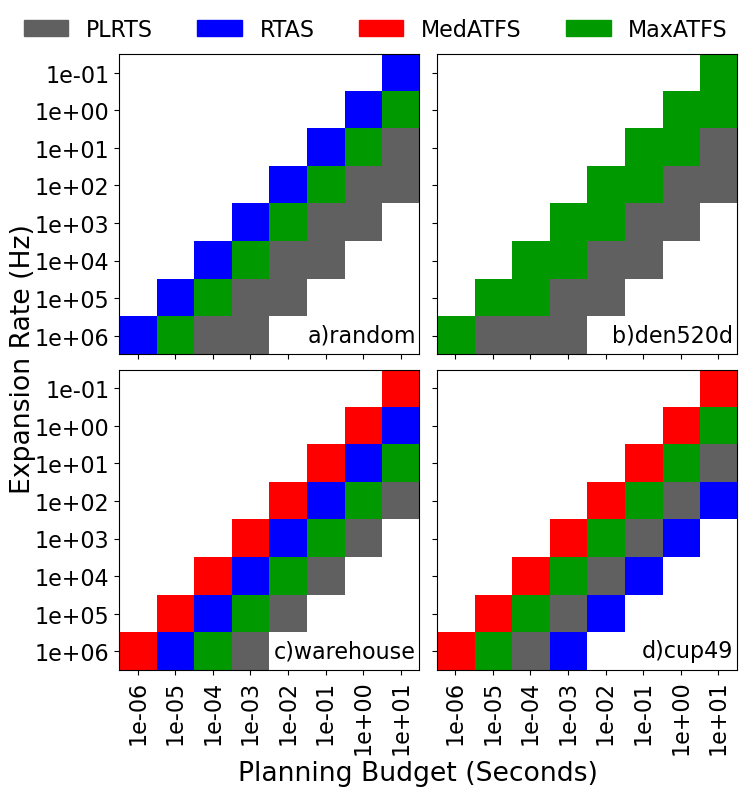

In [11]:
fig, axes = plt.subplots(ncols=2, nrows = 2, sharey=True, sharex = True, figsize = (8, 8))

folder = "../final_results/"
pattern = "*random*"

rates = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
budgets = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]

dat = []
print(len(glob(folder + pattern)))
for file_name in glob(folder + pattern):
    fn = file_name.replace(folder,"")
    try:
        #print(fn.replace(".out", "").split("_"))
        map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    search_time = float("inf")
    learn_time = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
            if "Search:" in line:
                search_time = float(line.split()[1])/10**6
                learn_time = float(line.split()[4])/10**6
                assert(line.split()[2] == "ms")
                assert(line.split()[5] == "ms")
    dat.append((map, alg, lookahead, rep, expansions, cost, search_time, learn_time))
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost", "searchrt", "learnrt"])

ers = defaultdict(list)

for expansion_rate in rates:
    for algorithm in set(data.Algorithm):
        dat = data.loc[data.Algorithm == algorithm]
        for lookahead in set(data.Lookahead):
            d = dat.loc[dat.Lookahead == lookahead]
            budget = []
            cost = []
            for i in range(len(d)):
                datum = d.iloc[i]
                cost.append(datum.cost)
                time_taken = datum.learnrt + datum.expansions/expansion_rate 
                budget.append(time_taken/datum.expansions*lookahead)
            ers[expansion_rate].append((algorithm, lookahead, np.median(cost), np.median(budget)))

res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3])):
            idx = int(np.floor(np.log10(sim[3])))
            current = res.loc[10**(idx), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx), expansion_rate] = sim
            except:
                res.loc[10**(idx), expansion_rate] = sim


im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

axes[0][0].imshow(im)
ax = axes[0][0]
ax.set_yticks(list(range(0,len(rate_fmt))))
ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt, rotation = 90)
#plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "upper left")
#plt.ylabel("Expansion Rate (Hz)")
#plt.xlabel("Planning Budget (Seconds)")
ax.text(7.4, 7.3, "a)random", ha = "right", va = "bottom")

ax.set_xlim([-0.5, 7.5])

fig.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], bbox_to_anchor=(0.9125, 0.95), ncol=4, frameon=False)






folder = "../final_results/"
pattern = "*den520*"

rates = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
budgets = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]

dat = []
print(len(glob(folder + pattern)))
for file_name in glob(folder + pattern):
    fn = file_name.replace(folder,"")
    try:
        #print(fn.replace(".out", "").split("_"))
        map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    search_time = float("inf")
    learn_time = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
            if "Search:" in line:
                search_time = float(line.split()[1])/10**6
                learn_time = float(line.split()[4])/10**6
                assert(line.split()[2] == "ms")
                assert(line.split()[5] == "ms")
    dat.append((map, alg, lookahead, rep, expansions, cost, search_time, learn_time))
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost", "searchrt", "learnrt"])

ers = defaultdict(list)

for expansion_rate in rates:
    for algorithm in set(data.Algorithm):
        dat = data.loc[data.Algorithm == algorithm]
        for lookahead in set(data.Lookahead):
            d = dat.loc[dat.Lookahead == lookahead]
            budget = []
            cost = []
            for i in range(len(d)):
                datum = d.iloc[i]
                cost.append(datum.cost)
                time_taken = datum.learnrt + datum.expansions/expansion_rate 
                budget.append(time_taken/datum.expansions*lookahead)
            ers[expansion_rate].append((algorithm, lookahead, np.median(cost), np.median(budget)))

res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3])):
            idx = int(np.floor(np.log10(sim[3])))
            current = res.loc[10**(idx), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx), expansion_rate] = sim
            except:
                res.loc[10**(idx), expansion_rate] = sim


im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

axes[0][1].imshow(im)
ax = axes[0][1]
ax.set_yticks(list(range(0,len(rate_fmt))))
ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt, rotation = 90)
#plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "upper left")
#plt.ylabel("Expansion Rate (Hz)")
#plt.xlabel("Planning Budget (Seconds)")
ax.text(7.4, 7.3, "b)den520d", ha = "right", va = "bottom")

ax.set_xlim([-0.5, 7.5])










folder = "../final_results/"
pattern = "*warehouse*"

rates = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
budgets = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]

dat = []
print(len(glob(folder + pattern)))
for file_name in glob(folder + pattern):
    fn = file_name.replace(folder,"")
    try:
        #print(fn.replace(".out", "").split("_"))
        map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    search_time = float("inf")
    learn_time = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
            if "Search:" in line:
                search_time = float(line.split()[1])/10**6
                learn_time = float(line.split()[4])/10**6
                assert(line.split()[2] == "ms")
                assert(line.split()[5] == "ms")
    dat.append((map, alg, lookahead, rep, expansions, cost, search_time, learn_time))
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost", "searchrt", "learnrt"])

ers = defaultdict(list)

for expansion_rate in rates:
    for algorithm in set(data.Algorithm):
        dat = data.loc[data.Algorithm == algorithm]
        for lookahead in set(data.Lookahead):
            d = dat.loc[dat.Lookahead == lookahead]
            budget = []
            cost = []
            for i in range(len(d)):
                datum = d.iloc[i]
                cost.append(datum.cost)
                time_taken = datum.learnrt + datum.expansions/expansion_rate 
                budget.append(time_taken/datum.expansions*lookahead)
            ers[expansion_rate].append((algorithm, lookahead, np.median(cost), np.median(budget)))

res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3])):
            idx = int(np.floor(np.log10(sim[3])))
            current = res.loc[10**(idx), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx), expansion_rate] = sim
            except:
                res.loc[10**(idx), expansion_rate] = sim


im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

axes[1][0].imshow(im)
ax = axes[1][0]
ax.set_yticks(list(range(0,len(rate_fmt))))
ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt, rotation = 90)
#plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "upper left")
#plt.ylabel("Expansion Rate (Hz)")
#plt.xlabel("Planning Budget (Seconds)")
ax.text(7.4, 7.3, "c)warehouse", ha = "right", va = "bottom")

ax.set_xlim([-0.5, 7.5])











folder = "../final_results/"
pattern = "*cup*"

rates = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
budgets = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]

dat = []
print(len(glob(folder + pattern)))
for file_name in glob(folder + pattern):
    fn = file_name.replace(folder,"")
    try:
        #print(fn.replace(".out", "").split("_"))
        map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    search_time = float("inf")
    learn_time = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
            if "Search:" in line:
                search_time = float(line.split()[1])/10**6
                learn_time = float(line.split()[4])/10**6
                assert(line.split()[2] == "ms")
                assert(line.split()[5] == "ms")
    dat.append((map, alg, lookahead, rep, expansions, cost, search_time, learn_time))
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost", "searchrt", "learnrt"])

ers = defaultdict(list)

for expansion_rate in rates:
    for algorithm in set(data.Algorithm):
        dat = data.loc[data.Algorithm == algorithm]
        for lookahead in set(data.Lookahead):
            d = dat.loc[dat.Lookahead == lookahead]
            budget = []
            cost = []
            for i in range(len(d)):
                datum = d.iloc[i]
                cost.append(datum.cost)
                time_taken = datum.learnrt + datum.expansions/expansion_rate 
                budget.append(time_taken/datum.expansions*lookahead)
            ers[expansion_rate].append((algorithm, lookahead, np.median(cost), np.median(budget)))

res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3])):
            idx = int(np.floor(np.log10(sim[3])))
            current = res.loc[10**(idx), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx), expansion_rate] = sim
            except:
                res.loc[10**(idx), expansion_rate] = sim


im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

axes[1][1].imshow(im)
ax = axes[1][1]
ax.set_yticks(list(range(0,len(rate_fmt))))
#ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt, rotation = 90)
#plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "upper left")
#plt.ylabel("Expansion Rate (Hz)")
#plt.xlabel("Planning Budget (Seconds)")
ax.text(7.4, 7.3, "d)cup49", ha = "right", va = "bottom")
ax.set_xlim([-0.5, 7.5])
plt.subplots_adjust(hspace = 0.05, wspace = 0.05)
fig.supylabel("Expansion Rate (Hz)", x = -.01)
fig.supxlabel("Planning Budget (Seconds)", y = -0.035)
plt.show()

In [ ]:
folder = "../final_results/"
pattern = "*den520d*"

rates = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
budgets = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]

dat = []
print(len(glob(folder + pattern)))
for file_name in glob(folder + pattern):
    fn = file_name.replace(folder,"")
    try:
        #print(fn.replace(".out", "").split("_"))
        map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    search_time = float("inf")
    learn_time = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
            if "Search:" in line:
                search_time = float(line.split()[1])/10**6
                learn_time = float(line.split()[4])/10**6
                assert(line.split()[2] == "ms")
                assert(line.split()[5] == "ms")
    dat.append((map, alg, lookahead, rep, expansions, cost, search_time, learn_time))
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost", "searchrt", "learnrt"])

ers = defaultdict(list)

for expansion_rate in [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]:
    for algorithm in set(data.Algorithm):
        dat = data.loc[data.Algorithm == algorithm]
        for lookahead in set(data.Lookahead):
            d = dat.loc[dat.Lookahead == lookahead]
            budget = []
            cost = []
            for i in range(len(d)):
                datum = d.iloc[i]
                cost.append(datum.cost)
                time_taken = datum.learnrt + datum.expansions/expansion_rate 
                budget.append(time_taken/datum.expansions*lookahead)
            ers[expansion_rate].append((algorithm, lookahead, np.median(cost), np.median(budget)))

res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3])):
            idx = int(np.floor(np.log10(sim[3])))
            current = res.loc[10**(idx), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx), expansion_rate] = sim
            except:
                res.loc[10**(idx), expansion_rate] = sim


im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

plt.imshow(im)
ax = plt.gca()
ax.set_yticks(list(range(0,len(rate_fmt))))
ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt)
plt.xticks(rotation=90)
plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "lower right")
plt.ylabel("Expansion Rate (Hz)")
plt.xlabel("Planning Budget (Seconds)")
plt.xlim([-0.5, 7.5])
plt.tight_layout()
plt.savefig("den520d_final_res.png")

In [ ]:
folder = "../final_results/"
pattern = "*warehouse*"

rates = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
budgets = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]

dat = []
print(len(glob(folder + pattern)))
for file_name in glob(folder + pattern):
    fn = file_name.replace(folder,"")
    try:
        #print(fn.replace(".out", "").split("_"))
        map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    search_time = float("inf")
    learn_time = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
            if "Search:" in line:
                search_time = float(line.split()[1])/10**6
                learn_time = float(line.split()[4])/10**6
                assert(line.split()[2] == "ms")
                assert(line.split()[5] == "ms")
    dat.append((map, alg, lookahead, rep, expansions, cost, search_time, learn_time))
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost", "searchrt", "learnrt"])

ers = defaultdict(list)

for expansion_rate in [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]:
    for algorithm in set(data.Algorithm):
        dat = data.loc[data.Algorithm == algorithm]
        for lookahead in set(data.Lookahead):
            d = dat.loc[dat.Lookahead == lookahead]
            budget = []
            cost = []
            for i in range(len(d)):
                datum = d.iloc[i]
                cost.append(datum.cost)
                time_taken = datum.learnrt + datum.expansions/expansion_rate 
                budget.append(time_taken/datum.expansions*lookahead)
            ers[expansion_rate].append((algorithm, lookahead, np.median(cost), np.median(budget)))

res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3])):
            idx = int(np.floor(np.log10(sim[3])))
            current = res.loc[10**(idx), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx), expansion_rate] = sim
            except:
                res.loc[10**(idx), expansion_rate] = sim


im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

plt.imshow(im)
ax = plt.gca()
ax.set_yticks(list(range(0,len(rate_fmt))))
ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt)
plt.xticks(rotation=90)
plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "lower right")
plt.ylabel("Expansion Rate (Hz)")
plt.xlabel("Planning Budget (Seconds)")
plt.xlim([-0.5, 7.5])
plt.tight_layout()
plt.savefig("warehouse_final_res.png")

In [ ]:
folder = "../final_results/"
pattern = "*cup*"

rates = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
budgets = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]

dat = []
print(len(glob(folder + pattern)))
for file_name in glob(folder + pattern):
    fn = file_name.replace(folder,"")
    try:
        #print(fn.replace(".out", "").split("_"))
        map, alg, lookahead, rep = fn.replace(".out", "").split("_")[-4:]
    except:
        continue
    lookahead = int(lookahead)
    cost = float("inf")
    expansions = float("inf")
    search_time = float("inf")
    learn_time = float("inf")
    with open(file_name) as f:
        for line in f.readlines():
            if "Arrival time:" in line:
                cost = float(line.split(": ")[1])
            if "Nodes expanded:" in line:
                expansions = int(line.split("Nodes expanded: ")[1].split()[0])
            if "Search:" in line:
                search_time = float(line.split()[1])/10**6
                learn_time = float(line.split()[4])/10**6
                assert(line.split()[2] == "ms")
                assert(line.split()[5] == "ms")
    dat.append((map, alg, lookahead, rep, expansions, cost, search_time, learn_time))
data = pd.DataFrame(dat, columns = ["Map", "Algorithm", "Lookahead", "rep", "expansions", "cost", "searchrt", "learnrt"])

ers = defaultdict(list)

for expansion_rate in [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]:
    for algorithm in set(data.Algorithm):
        dat = data.loc[data.Algorithm == algorithm]
        for lookahead in set(data.Lookahead):
            d = dat.loc[dat.Lookahead == lookahead]
            budget = []
            cost = []
            for i in range(len(d)):
                datum = d.iloc[i]
                cost.append(datum.cost)
                time_taken = datum.learnrt + datum.expansions/expansion_rate 
                budget.append(time_taken/datum.expansions*lookahead)
            ers[expansion_rate].append((algorithm, lookahead, np.median(cost), np.median(budget)))

res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3])):
            idx = int(np.floor(np.log10(sim[3])))
            current = res.loc[10**(idx), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx), expansion_rate] = sim
            except:
                res.loc[10**(idx), expansion_rate] = sim


im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

plt.imshow(im)
ax = plt.gca()
ax.set_yticks(list(range(0,len(rate_fmt))))
ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt)
plt.xticks(rotation=90)
plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "lower right")
plt.ylabel("Expansion Rate (Hz)")
plt.xlabel("Planning Budget (Seconds)")
plt.xlim([-0.5, 7.5])
plt.tight_layout()
plt.savefig("cup_final_res.png")

In [ ]:
fig.show()

In [ ]:
res = pd.DataFrame(None, index = budgets, columns = rates).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in rates:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3]) and (sim[0] == "rtasipp")):
            idx = min(max(0, int(np.floor(np.log10(sim[3]))) +1), len(scale)-1)
            current = res.loc[10**(idx-1), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx-1), expansion_rate] = sim
            except:
                res.loc[10**(idx-1), expansion_rate] = sim
res

In [ ]:
res

In [ ]:
res = pd.DataFrame(None, index = scale, columns = scale).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in scale:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3]) and (sim[0] == "plrtosipp")):
            idx = min(max(0, int(np.floor(np.log10(sim[3]))) +1), len(scale)-1)
            current = res.loc[10**(idx-1), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx-1), expansion_rate] = sim
            except:
                res.loc[10**(idx-1), expansion_rate] = sim
res

In [ ]:
res = pd.DataFrame(None, index = scale, columns = scale).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in scale:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3]) and (sim[0] == "hybrid")):
            idx = min(max(0, int(np.floor(np.log10(sim[3]))) +1), len(scale)-1)
            current = res.loc[10**(idx-1), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx-1), expansion_rate] = sim
            except:
                res.loc[10**(idx-1), expansion_rate] = sim
res

In [ ]:
res = pd.DataFrame(None, index = scale, columns = scale).rename_axis("Budget").rename_axis("Expansion Rate", axis = 1)
for expansion_rate in scale:
    for sim in ers[expansion_rate]:
        if(np.isfinite(sim[3]) and (sim[0] == "plrtosipphonly")):
            idx = min(max(0, int(np.floor(np.log10(sim[3]))) +1), len(scale)-1)
            current = res.loc[10**(idx-1), expansion_rate]
            try:
                if (current[2] > sim[2]):
                    res.loc[10**(idx-1), expansion_rate] = sim
            except:
                res.loc[10**(idx-1), expansion_rate] = sim
res

In [ ]:
thecolor = {
    "hybrid":(0, 200, 0),
    "plrtosipp":(255, 0, 0),
    "plrtosipphonly": (0, 0, 255),
    "rtasipp": ()
}

In [ ]:
im = np.ones((len(res.columns),len(res), 3), dtype = int)*
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]

In [ ]:
im = np.ones((len(res.columns),len(res), 3), dtype = int)*255
for i in range(len(res)):
    for j in range(len(res.columns)):
        d = res.iloc[i,j]
        if type(d) == type((0,1)):
            im[j,i, :] = thecolor[d[0]]
            plrtosipphonly_patch = mpatches.Patch(color =np.asarray(thecolor["plrtosipphonly"])/255, label='PLRTS')
rtasipp_patch = mpatches.Patch(color=np.asarray(thecolor["rtasipp"])/255, label='RTAS')
hybrid_patch = mpatches.Patch(color=np.asarray(thecolor["hybrid"])/255, label='MedATFS')
plrtosipp_patch = mpatches.Patch(color=np.asarray(thecolor["plrtosipp"])/255, label='MaxATFS')

plt.imshow(im)
ax = plt.gca()
ax.set_yticks(list(range(0,len(rate_fmt))))
ax.set_yticklabels(rate_fmt)
ax.set_xticks(list(range(0,len(budget_fmt))))
ax.set_xticklabels(budget_fmt)
plt.xticks(rotation=90)
plt.legend(handles = [plrtosipphonly_patch, rtasipp_patch, hybrid_patch, plrtosipp_patch], loc = "lower right")
plt.ylabel("Expansion Rate (Hz)")
plt.xlabel("Planning Budget (Seconds)")

In [7]:
budget_fmt = []
for b in budgets:
    budget_fmt.append('{:.0e}'.format(b))
rate_fmt = []
for r in rates:
    rate_fmt.append('{:.0e}'.format(r))